<a href="https://colab.research.google.com/github/Pickle1200/ma-crossover-backtest/blob/main/MA_crossover_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import pandas as pd

data = yf.download("SPY", start="2015-01-01", end="2025-01-01", auto_adjust=True)
close = data["Close"]
close = data["Close"]["SPY"]

print(close.head())
print(close.tail())

[*********************100%***********************]  1 of 1 completed

Date
2015-01-02    169.687851
2015-01-05    166.623413
2015-01-06    165.053909
2015-01-07    167.110657
2015-01-08    170.076050
Name: SPY, dtype: float64
Date
2024-12-24    591.179077
2024-12-26    591.218384
2024-12-27    584.994995
2024-12-30    578.319275
2024-12-31    576.215271
Name: SPY, dtype: float64


In [2]:
short_ma = close.rolling(20).mean()
long_ma  = close.rolling(50).mean()

print(long_ma.head(55))

Date
2015-01-02           NaN
2015-01-05           NaN
2015-01-06           NaN
2015-01-07           NaN
2015-01-08           NaN
2015-01-09           NaN
2015-01-12           NaN
2015-01-13           NaN
2015-01-14           NaN
2015-01-15           NaN
2015-01-16           NaN
2015-01-20           NaN
2015-01-21           NaN
2015-01-22           NaN
2015-01-23           NaN
2015-01-26           NaN
2015-01-27           NaN
2015-01-28           NaN
2015-01-29           NaN
2015-01-30           NaN
2015-02-02           NaN
2015-02-03           NaN
2015-02-04           NaN
2015-02-05           NaN
2015-02-06           NaN
2015-02-09           NaN
2015-02-10           NaN
2015-02-11           NaN
2015-02-12           NaN
2015-02-13           NaN
2015-02-17           NaN
2015-02-18           NaN
2015-02-19           NaN
2015-02-20           NaN
2015-02-23           NaN
2015-02-24           NaN
2015-02-25           NaN
2015-02-26           NaN
2015-02-27           NaN
2015-03-02          

In [3]:
position = (short_ma > long_ma).astype(int)

print(position.head(55))
print(position.tail())

Date
2015-01-02    0
2015-01-05    0
2015-01-06    0
2015-01-07    0
2015-01-08    0
2015-01-09    0
2015-01-12    0
2015-01-13    0
2015-01-14    0
2015-01-15    0
2015-01-16    0
2015-01-20    0
2015-01-21    0
2015-01-22    0
2015-01-23    0
2015-01-26    0
2015-01-27    0
2015-01-28    0
2015-01-29    0
2015-01-30    0
2015-02-02    0
2015-02-03    0
2015-02-04    0
2015-02-05    0
2015-02-06    0
2015-02-09    0
2015-02-10    0
2015-02-11    0
2015-02-12    0
2015-02-13    0
2015-02-17    0
2015-02-18    0
2015-02-19    0
2015-02-20    0
2015-02-23    0
2015-02-24    0
2015-02-25    0
2015-02-26    0
2015-02-27    0
2015-03-02    0
2015-03-03    0
2015-03-04    0
2015-03-05    0
2015-03-06    0
2015-03-09    0
2015-03-10    0
2015-03-11    0
2015-03-12    0
2015-03-13    0
2015-03-16    1
2015-03-17    1
2015-03-18    1
2015-03-19    1
2015-03-20    1
2015-03-23    1
Name: SPY, dtype: int64
Date
2024-12-24    1
2024-12-26    1
2024-12-27    1
2024-12-30    1
2024-12-31    1
Name: 

In [4]:
position_lagged = position.shift(1)

print(position_lagged.head(52))

Date
2015-01-02    NaN
2015-01-05    0.0
2015-01-06    0.0
2015-01-07    0.0
2015-01-08    0.0
2015-01-09    0.0
2015-01-12    0.0
2015-01-13    0.0
2015-01-14    0.0
2015-01-15    0.0
2015-01-16    0.0
2015-01-20    0.0
2015-01-21    0.0
2015-01-22    0.0
2015-01-23    0.0
2015-01-26    0.0
2015-01-27    0.0
2015-01-28    0.0
2015-01-29    0.0
2015-01-30    0.0
2015-02-02    0.0
2015-02-03    0.0
2015-02-04    0.0
2015-02-05    0.0
2015-02-06    0.0
2015-02-09    0.0
2015-02-10    0.0
2015-02-11    0.0
2015-02-12    0.0
2015-02-13    0.0
2015-02-17    0.0
2015-02-18    0.0
2015-02-19    0.0
2015-02-20    0.0
2015-02-23    0.0
2015-02-24    0.0
2015-02-25    0.0
2015-02-26    0.0
2015-02-27    0.0
2015-03-02    0.0
2015-03-03    0.0
2015-03-04    0.0
2015-03-05    0.0
2015-03-06    0.0
2015-03-09    0.0
2015-03-10    0.0
2015-03-11    0.0
2015-03-12    0.0
2015-03-13    0.0
2015-03-16    0.0
2015-03-17    1.0
2015-03-18    1.0
Name: SPY, dtype: float64


In [5]:
asset_returns = close.pct_change()
strategy_returns = position_lagged * asset_returns

print(strategy_returns.head(55))
print(strategy_returns.describe())

Date
2015-01-02         NaN
2015-01-05   -0.000000
2015-01-06   -0.000000
2015-01-07    0.000000
2015-01-08    0.000000
2015-01-09   -0.000000
2015-01-12   -0.000000
2015-01-13   -0.000000
2015-01-14   -0.000000
2015-01-15   -0.000000
2015-01-16    0.000000
2015-01-20    0.000000
2015-01-21    0.000000
2015-01-22    0.000000
2015-01-23   -0.000000
2015-01-26    0.000000
2015-01-27   -0.000000
2015-01-28   -0.000000
2015-01-29    0.000000
2015-01-30   -0.000000
2015-02-02    0.000000
2015-02-03    0.000000
2015-02-04   -0.000000
2015-02-05    0.000000
2015-02-06   -0.000000
2015-02-09   -0.000000
2015-02-10    0.000000
2015-02-11    0.000000
2015-02-12    0.000000
2015-02-13    0.000000
2015-02-17    0.000000
2015-02-18    0.000000
2015-02-19   -0.000000
2015-02-20    0.000000
2015-02-23   -0.000000
2015-02-24    0.000000
2015-02-25   -0.000000
2015-02-26   -0.000000
2015-02-27   -0.000000
2015-03-02    0.000000
2015-03-03   -0.000000
2015-03-04   -0.000000
2015-03-05    0.000000
2015-0

In [6]:
strategy_returns = strategy_returns.fillna(0)
total_growth = (1 + strategy_returns).cumprod()

print(total_growth.tail())           # final value = total growth of £1
total_return = total_growth.iloc[-1] - 1
print("Total return:", total_return)

Date
2024-12-24    2.198145
2024-12-26    2.198292
2024-12-27    2.175151
2024-12-30    2.150330
2024-12-31    2.142506
Name: SPY, dtype: float64
Total return: 1.1425063521244248


In [7]:
bh_returns = asset_returns.fillna(0)
bh_growth = (1 + bh_returns).cumprod()

bh_total_return = bh_growth.iloc[-1] - 1
print("Strategy total return:", total_return)
print("Buy & hold total return:", bh_total_return)

Strategy total return: 1.1425063521244248
Buy & hold total return: 2.3957367469907216


In [8]:
import numpy as np

sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252)
bh_sharpe = (bh_returns.mean() / bh_returns.std()) * np.sqrt(252)

print("Strategy Sharpe:", sharpe)
print("Buy & hold Sharpe:", bh_sharpe)

Strategy Sharpe: 0.7314645011109598
Buy & hold Sharpe: 0.7837082079229531


In [9]:
running_max = total_growth.cummax()
drawdown = total_growth / running_max - 1
max_drawdown = drawdown.min()

bh_running_max = bh_growth.cummax()
bh_drawdown = bh_growth / bh_running_max - 1
bh_max_drawdown = bh_drawdown.min()

print("Strategy max drawdown:", max_drawdown)
print("Buy & hold max drawdown:", bh_max_drawdown)

Strategy max drawdown: -0.28887071632075545
Buy & hold max drawdown: -0.33717282419038563


In [10]:
trades = position_lagged.diff().abs()
cost_per_trade = 0.001
strategy_returns_net = strategy_returns - trades * cost_per_trade

print("Total trade-days:", trades.sum())

net_growth = (1 + strategy_returns_net.fillna(0)).cumprod()
net_total_return = net_growth.iloc[-1] - 1
net_sharpe = (strategy_returns_net.mean() / strategy_returns_net.std()) * np.sqrt(252)

print("Net total return:", net_total_return, " (gross was:", total_return, ")")
print("Net Sharpe:", net_sharpe, " (gross was:", sharpe, ")")

Total trade-days: 47.0
Net total return: 1.0440355774369512  (gross was: 1.1425063521244248 )
Net Sharpe: 0.6897872819498603  (gross was: 0.7314645011109598 )


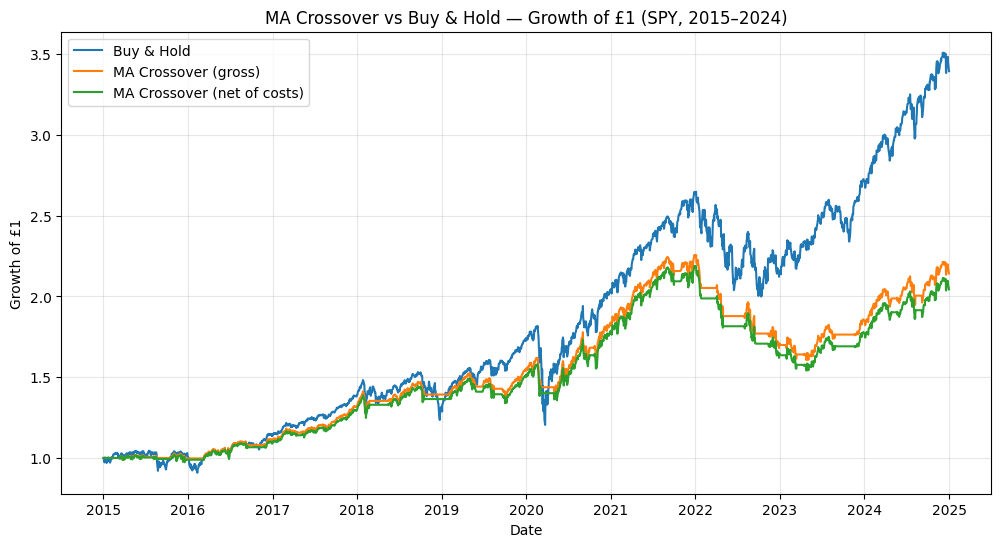

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(bh_growth, label="Buy & Hold")
plt.plot(total_growth, label="MA Crossover (gross)")
plt.plot(net_growth, label="MA Crossover (net of costs)")

plt.title("MA Crossover vs Buy & Hold — Growth of £1 (SPY, 2015–2024)")
plt.xlabel("Date")
plt.ylabel("Growth of £1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("equity_curves.png", dpi=150, bbox_inches="tight")
plt.show()